# TDT implementation of OpenGATE Dose Map Fundamentals from **CT in HU** + Activity Map

This notebook is a **step-by-step educational build-up** toward generating a **3D dose map** in **OpenGATE Python** from:

1. a **patient CT image in Hounsfield Units (HU)** stored as a NIfTI file, and  
2. a **registered 3D activity map** stored as a NIfTI file, where voxel values are in **MBq/mL**.

---

## What OpenGATE is doing conceptually

OpenGATE is a Python interface to **GATE / Geant4**, which are Monte Carlo particle-transport tools. In this notebook, the important idea is:

- the **CT image in HU** defines the **voxelized anatomy**
- the CT is **not** used directly as “dose” or as a raw attenuation map
- instead, OpenGATE converts HU into **materials voxel-by-voxel** using its built-in HU-to-material workflow
- then Geant4 transports particles through those materials using the physics model
- the **activity image** tells OpenGATE **where decays / emissions come from**
- the **DoseActor** scores deposited energy and dose on a voxel grid

So the workflow is:

**CT in HU → OpenGATE HU-to-material conversion → voxelized anatomy**  
**Activity map → voxelized source distribution**  
**Monte Carlo transport → energy deposition / dose map**

---

## What this notebook teaches

The notebook builds up in layers:

1. verify OpenGATE is installed  
2. run a tiny simulation with a simple gamma source  
3. add a water phantom and a `DoseActor`  
4. build a **toy CT image in HU** and use it as an OpenGATE image volume  
5. add a **small random source** inside that CT to verify image-based transport  
6. build a **toy liver activity image** in the same registration  
7. switch to a **voxelized source** using the activity image  
8. scale the Monte Carlo output using the total activity  
---

## Important practical notes

- The CT and activity maps should be in the **same physical space**.
- OpenGATE image volumes are placed by their **image box center** by default, so registration/origin handling matters.
- For teaching, this notebook uses a **monoenergetic gamma source** so the source model stays easy to understand.
- For real therapy dosimetry, you would later replace that with a more realistic radionuclide emission model and time integration workflow.

--- 

For any further questions please email pyazdi@bccrc.ca

## Check if OpenGATE is installed correctly


In [11]:
import opengate as gate

sim = gate.Simulation()
sim.g4_verbose = False
sim.visu = False
sim.number_of_threads = 1

stats = sim.add_actor("SimulationStatisticsActor", "Stats")

sim.run(start_new_process=True)

print(stats)


Dispatching simulation to subprocess ...
⚠️ No configured source, no particle will be generated.
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 0.4 seconds.
--------------------------------------------------------------------------------
⚠️ One warning occurred in this simulation:
⚠️ (1) No configured source, no particle will be generated.
runs                1 
events              1 
tracks              1 
steps               0 
init                393.56 ms
duration            135.0 us
pps                 7407 
tps                 7407 
sps                 0 
start_time          

## Simple test of a simulation

This is the smallest meaningful “physics” example:

- a large air world
- a tiny spherical source
- isotropic emission
- monoenergetic 140 keV gamma particles

There is no patient yet. This is just a confidence check that particle generation and transport work.


In [12]:

import opengate as gate

# units
m = gate.g4_units.m
cm = gate.g4_units.cm
mm = gate.g4_units.mm
keV = gate.g4_units.keV
Bq = gate.g4_units.Bq

# simulation
sim = gate.Simulation()
sim.g4_verbose = False
sim.visu = False
sim.number_of_threads = 1

# world
sim.world.size = [1 * m, 1 * m, 1 * m]
sim.world.material = "G4_AIR"

# simple gamma source
source = sim.add_source("GenericSource", "src")
source.particle = "gamma"
source.activity = 1000 * Bq

source.position.type = "sphere"
source.position.radius = 5 * mm
source.position.translation = [0, 0, 0]

source.direction.type = "iso"

source.energy.type = "mono"
source.energy.mono = 140 * keV

# stats actor
stats = sim.add_actor("SimulationStatisticsActor", "Stats")

# run
sim.run(start_new_process=True)

print(stats)


Dispatching simulation to subprocess ...
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 0.4 seconds.
--------------------------------------------------------------------------------
runs                1 
events              1031 
tracks              1059 
steps               1093 
init                400.718 ms
duration            2.371 ms
pps                 434837 
tps                 446646 
sps                 460986 
start_time          Tue Mar 17 13:40:23 2026 
stop_time           Tue Mar 17 13:40:24 2026 
sim_start_time      0.0 ps
sim_stop_time       1.0 s
threads         

## Adding a box phantom + DoseActor

Now we move from “just a source” to the first real dosimetry object:

- a water box phantom
- a source inside it
- a `DoseActor` attached to the box
- scored energy deposition and dose on a 3D grid

This section is important because the same scoring logic will later be reused for the voxelized patient image.


#### Imports and units


In [13]:

import opengate as gate
import numpy as np
from pathlib import Path

# units
m = gate.g4_units.m
cm = gate.g4_units.cm
mm = gate.g4_units.mm
keV = gate.g4_units.keV
Bq = gate.g4_units.Bq


#### Create the simulation and world


In [14]:

sim = gate.Simulation()

sim.g4_verbose = False
sim.visu = False
sim.number_of_threads = 1
sim.output_dir = Path("opengate_example")

# world
sim.world.size = [1 * m, 1 * m, 1 * m]
sim.world.material = "G4_AIR"


#### Add a simple water phantom


In [15]:

waterbox = sim.add_volume("Box", "waterbox")
waterbox.size = [10 * cm, 10 * cm, 10 * cm]
waterbox.material = "G4_WATER"
waterbox.translation = [0, 0, 0]


#### Add a source inside the box


In [16]:

source = sim.add_source("GenericSource", "src")

source.particle = "gamma"
source.n = 20000

source.position.type = "sphere"
source.position.radius = 3 * mm
source.position.translation = [0, 0, 0]

source.direction.type = "iso"

source.energy.type = "mono"
source.energy.mono = 140 * keV


#### Add the statistics actor


In [17]:

stats = sim.add_actor("SimulationStatisticsActor", "Stats")


#### Add the dose actor


In [18]:

dose = sim.add_actor("DoseActor", "dose")

# attach scoring to the water box
dose.attached_to = waterbox

# scoring grid
dose.size = [50, 50, 50]
dose.spacing = [2 * mm, 2 * mm, 2 * mm]

# turn on extra outputs
dose.dose.active = True
dose.dose_uncertainty.active = True

# output files
dose.edep.output_filename = "waterbox_edep.mhd"
dose.dose.output_filename = "waterbox_dose.mhd"
dose.dose_uncertainty.output_filename = "waterbox_dose_uncertainty.mhd"


#### Run the simulation


In [19]:

sim.run(start_new_process=True)


Dispatching simulation to subprocess ...
Simulation: create RunManager (single thread)
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 2.3 seconds.
--------------------------------------------------------------------------------


#### Inspect results


In [20]:

print(stats)

print("Edep file :", dose.edep.get_output_path())
print("Dose file :", dose.dose.get_output_path())
print("Dose unc. :", dose.dose_uncertainty.get_output_path())


runs                1 
events              20000 
tracks              20370 
steps               65097 
init                2.1725 s
duration            85.25 ms
pps                 234604 
tps                 238944 
sps                 763601 
start_time          Tue Mar 17 13:40:39 2026 
stop_time           Tue Mar 17 13:40:41 2026 
sim_start_time      0.0 ps
sim_stop_time       1.0 s
threads             1 
arch                Linux 
python              3.11.14 
Edep file : /home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/opengate_example/waterbox_edep.mhd
Dose file : /home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/opengate_example/waterbox_dose.mhd
Dose unc. : /home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/opengate_example/waterbox_dose_uncertainty.mhd


#### Inspect the dose in memory


In [21]:

dose_img = dose.dose.image
dose_arr = np.asarray(dose_img)

print("Dose array shape:", dose_arr.shape)
print("Max dose voxel :", dose_arr.max())
print("Total dose sum :", dose_arr.sum())


Dose array shape: (50, 50, 50)
Max dose voxel : 1.0715069966207884e-07
Total dose sum : 1.0026524936754877e-05


#### Quick central slice plot

`np.asarray()` on the OpenGATE image is typically easiest to think of as an array in **(z, y, x)** order for plotting.


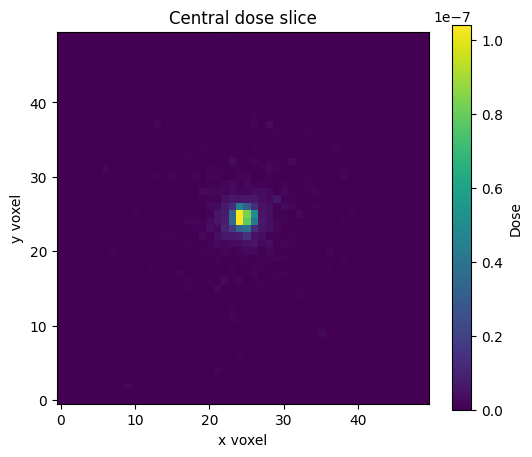

In [22]:

import matplotlib.pyplot as plt

k = dose_arr.shape[0] // 2
plt.figure(figsize=(6, 5))
plt.imshow(dose_arr[k], origin="lower")
plt.colorbar(label="Dose")
plt.title("Central dose slice")
plt.xlabel("x voxel")
plt.ylabel("y voxel")
plt.show()


## Utilities we will use for voxelized CT + activity work

These helper functions do four main jobs:

1. read / write NIfTI images with SimpleITK  
2. visualize 3D arrays cleanly  
3. compute total activity from an image in **MBq/mL**
4. run a reusable OpenGATE simulation with:
   - a CT image in HU as the patient geometry
   - either a point-like source or a voxelized source


In [23]:

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
import opengate as gate


In [24]:

def summarize_array(arr, name="array"):
    arr = np.asarray(arr)
    print(f"{name}:")
    print(f"  shape = {arr.shape}")
    print(f"  dtype = {arr.dtype}")
    print(f"  min   = {arr.min()}")
    print(f"  max   = {arr.max()}")
    print(f"  mean  = {arr.mean()}")
    print(f"  sum   = {arr.sum()}")
    print()


def show_orthogonal_slices(arr, title="", cmap="gray", cbar_label="", vmin=None, vmax=None):
    arr = np.asarray(arr)
    zc = arr.shape[0] // 2
    yc = arr.shape[1] // 2
    xc = arr.shape[2] // 2

    fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = ax[0].imshow(arr[zc], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,aspect = 'auto')
    ax[0].set_title(f"{title}\nAxial (z={zc})")
    ax[0].set_xlabel("x voxel")
    ax[0].set_ylabel("y voxel")

    im1 = ax[1].imshow(arr[:, yc, :], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,aspect = 'auto')
    ax[1].set_title(f"{title}\nCoronal (y={yc})")
    ax[1].set_xlabel("x voxel")
    ax[1].set_ylabel("z voxel")

    im2 = ax[2].imshow(arr[:, :, xc], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,aspect = 'auto')
    ax[2].set_title(f"{title}\nSagittal (x={xc})")
    ax[2].set_xlabel("y voxel")
    ax[2].set_ylabel("z voxel")

    cbar = fig.colorbar(im2)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()


def show_overlay_orthogonal(
    background_arr,
    overlay_arr,
    background_title="Background",
    overlay_title="Overlay",
    background_cmap="gray",
    overlay_cmap="inferno",
    alpha=0.55,
    bg_vmin=None,
    bg_vmax=None,
    ov_vmin=None,
    ov_vmax=None,
):
    bg = np.asarray(background_arr)
    ov = np.asarray(overlay_arr)

    zc = bg.shape[0] // 2
    yc = bg.shape[1] // 2
    xc = bg.shape[2] // 2

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].imshow(bg[zc], origin="lower", cmap=background_cmap, vmin=bg_vmin, vmax=bg_vmax)
    im0 = ax[0].imshow(ov[zc], origin="lower", cmap=overlay_cmap, alpha=alpha, vmin=ov_vmin, vmax=ov_vmax,aspect = 'auto')
    ax[0].set_title(f"Axial\n{background_title} + {overlay_title}")

    ax[1].imshow(bg[:, yc, :], origin="lower", cmap=background_cmap, vmin=bg_vmin, vmax=bg_vmax)
    im1 = ax[1].imshow(ov[:, yc, :], origin="lower", cmap=overlay_cmap, alpha=alpha, vmin=ov_vmin, vmax=ov_vmax,aspect = 'auto')
    ax[1].set_title(f"Coronal\n{background_title} + {overlay_title}")

    ax[2].imshow(bg[:, :, xc], origin="lower", cmap=background_cmap, vmin=bg_vmin, vmax=bg_vmax)
    im2 = ax[2].imshow(ov[:, :, xc], origin="lower", cmap=overlay_cmap, alpha=alpha, vmin=ov_vmin, vmax=ov_vmax,aspect = 'auto')
    ax[2].set_title(f"Sagittal\n{background_title} + {overlay_title}")

    for a in ax:
        a.set_xlabel("voxel")
        a.set_ylabel("voxel")

    cbar = fig.colorbar(im2)
    cbar.set_label(overlay_title)
    plt.tight_layout()
    plt.show()


def make_sitk_image_from_zyx(arr_zyx, spacing_xyz_mm, origin_xyz_mm):
    img = sitk.GetImageFromArray(np.asarray(arr_zyx))
    img.SetSpacing(tuple(float(v) for v in spacing_xyz_mm))
    img.SetOrigin(tuple(float(v) for v in origin_xyz_mm))
    img.SetDirection(np.eye(3).ravel())
    return img


def save_array_like_reference(reference_img, arr_zyx, out_path):
    out_path = Path(out_path)
    out_img = sitk.GetImageFromArray(np.asarray(arr_zyx))
    out_img.CopyInformation(reference_img)
    sitk.WriteImage(out_img, str(out_path))
    return out_path


def compute_total_activity_bq_from_mbqml(activity_nii_path):
    activity_nii_path = Path(activity_nii_path)
    img = sitk.ReadImage(str(activity_nii_path))
    arr = sitk.GetArrayFromImage(img).astype(np.float64)  # (z, y, x)

    spacing_x, spacing_y, spacing_z = img.GetSpacing()
    voxel_volume_mm3 = spacing_x * spacing_y * spacing_z
    voxel_volume_ml = voxel_volume_mm3 / 1000.0

    total_activity_mbq = float(np.sum(arr) * voxel_volume_ml)
    total_activity_bq = total_activity_mbq * 1e6 

    return total_activity_bq, total_activity_mbq, voxel_volume_ml, img, arr




In [25]:
def find_gate_hu_material_tables():
    """
    Try to locate the HU-conversion reference tables that OpenGATE uses with
    gate.geometry.materials.HounsfieldUnit_to_material(...).

    Most installs place these in an OpenGATE tests/data directory. This helper
    keeps the notebook user-facing workflow simple: the notebook tries to find
    them automatically so you do not have to manually type table paths.
    """
    gate_pkg_dir = Path(gate.__file__).resolve().parent

    candidate_roots = [
        gate_pkg_dir,
        gate_pkg_dir.parent,
        *list(gate_pkg_dir.parents[:4]),
    ]

    relative_pairs = [
        (
            Path("tests/data/Schneider2000MaterialsTable.txt"),
            Path("tests/data/Schneider2000DensitiesTable.txt"),
        ),
        (
            Path("opengate/tests/data/Schneider2000MaterialsTable.txt"),
            Path("opengate/tests/data/Schneider2000DensitiesTable.txt"),
        ),
    ]

    for root in candidate_roots:
        for mat_rel, den_rel in relative_pairs:
            mat_path = root / mat_rel
            den_path = root / den_rel
            if mat_path.exists() and den_path.exists():
                return mat_path, den_path

    # Fallback: exact-name recursive search near the package location
    material_hits = []
    density_hits = []
    for root in candidate_roots[:2]:
        try:
            material_hits.extend(root.rglob("Schneider2000MaterialsTable.txt"))
            density_hits.extend(root.rglob("Schneider2000DensitiesTable.txt"))
        except Exception:
            pass

    if material_hits and density_hits:
        return material_hits[0], density_hits[0]

    raise FileNotFoundError(
        "Could not automatically locate OpenGATE's HU conversion tables. "
        "Check that your OpenGATE installation includes the tests/data files "
        "used by gate.geometry.materials.HounsfieldUnit_to_material(...)."
    )


def get_gate_hu_voxel_materials(
    sim,
    density_tolerance_gcm3=0.05,
    materials_table_path=None,
    densities_table_path=None,
):
    """
    Build the voxel_materials interval list using OpenGATE's built-in
    HU-to-material conversion helper.
    """
    gcm3 = gate.g4_units.g_cm3

    if materials_table_path is None or densities_table_path is None:
        materials_table_path, densities_table_path = find_gate_hu_material_tables()

    voxel_materials, generated_materials = gate.geometry.materials.HounsfieldUnit_to_material(
        sim,
        float(density_tolerance_gcm3) * gcm3,
        str(materials_table_path),
        str(densities_table_path),
    )

    return voxel_materials, generated_materials, Path(materials_table_path), Path(densities_table_path)

## Build a toy CT image in HU and save it as NIfTI

We now create a synthetic patient-like CT in HU so the rest of the notebook is self-contained.

The toy anatomy will contain:

- air background: about **-1000 HU**
- soft-tissue body: about **40 HU**
- lungs: about **-750 HU**
- liver: about **70 HU**
- dense bone / spine: about **1000 HU**

This is not meant to be anatomically perfect. It is just a clean sandbox for learning image-volume transport.


In [26]:

DATA_DIR = Path("notebook_data_hu")
DATA_DIR.mkdir(exist_ok=True, parents=True)

toy_ct_hu_path = DATA_DIR / "toy_ct_hu.nii.gz"

# image shape in numpy order (z, y, x)
nz, ny, nx = 72, 128, 128
spacing_xyz_mm = (3.0, 3.0, 3.0)  # x, y, z spacing in mm

zz, yy, xx = np.mgrid[0:nz, 0:ny, 0:nx]

# start with air everywhere
toy_ct_hu = np.full((nz, ny, nx), -1000.0, dtype=np.float32)

# body ellipsoid
cz, cy, cx = nz / 2, ny / 2, nx / 2
body = (
    ((zz - cz) / (0.38 * nz)) ** 2
    + ((yy - cy) / (0.34 * ny)) ** 2
    + ((xx - cx) / (0.28 * nx)) ** 2
) <= 1.0
toy_ct_hu[body] = 40.0

# lungs (two ellipsoids inside body)
lung_left = (
    ((zz - cz) / (0.22 * nz)) ** 2
    + ((yy - (cy - 12)) / (0.16 * ny)) ** 2
    + ((xx - (cx - 16)) / (0.10 * nx)) ** 2
) <= 1.0

lung_right = (
    ((zz - cz) / (0.22 * nz)) ** 2
    + ((yy - (cy + 12)) / (0.16 * ny)) ** 2
    + ((xx - (cx - 16)) / (0.10 * nx)) ** 2
) <= 1.0

toy_ct_hu[lung_left | lung_right] = -750.0

# liver ellipsoid on the patient's right side
liver = (
    ((zz - (cz + 6)) / (0.13 * nz)) ** 2
    + ((yy - (cy + 14)) / (0.11 * ny)) ** 2
    + ((xx - (cx + 8)) / (0.12 * nx)) ** 2
) <= 1.0
toy_ct_hu[liver] = 70.0

# simple spine / dense bone cylinder
spine = (
    ((yy - cy) / (0.035 * ny)) ** 2
    + ((xx - (cx + 24)) / (0.03 * nx)) ** 2
) <= 1.0
spine &= np.abs(zz - cz) < 0.28 * nz
toy_ct_hu[spine] = 1000.0

toy_ct_img = make_sitk_image_from_zyx(
    toy_ct_hu,
    spacing_xyz_mm=spacing_xyz_mm,
    origin_xyz_mm=(0.0, 0.0, 0.0),
)
sitk.WriteImage(toy_ct_img, str(toy_ct_hu_path))

print(f"Saved toy CT HU image to: {toy_ct_hu_path}")
summarize_array(toy_ct_hu, "toy_ct_hu")


Saved toy CT HU image to: notebook_data_hu/toy_ct_hu.nii.gz
toy_ct_hu:
  shape = (72, 128, 128)
  dtype = float32
  min   = -1000.0
  max   = 1000.0
  mean  = -860.9662475585938
  sum   = -1015637120.0



#### Inspect the toy CT image


Toy CT size (x, y, z): (128, 128, 72)
Toy CT spacing (mm):   (3.0, 3.0, 3.0)
Toy CT origin:         (0.0, 0.0, 0.0)
Toy CT direction:      (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


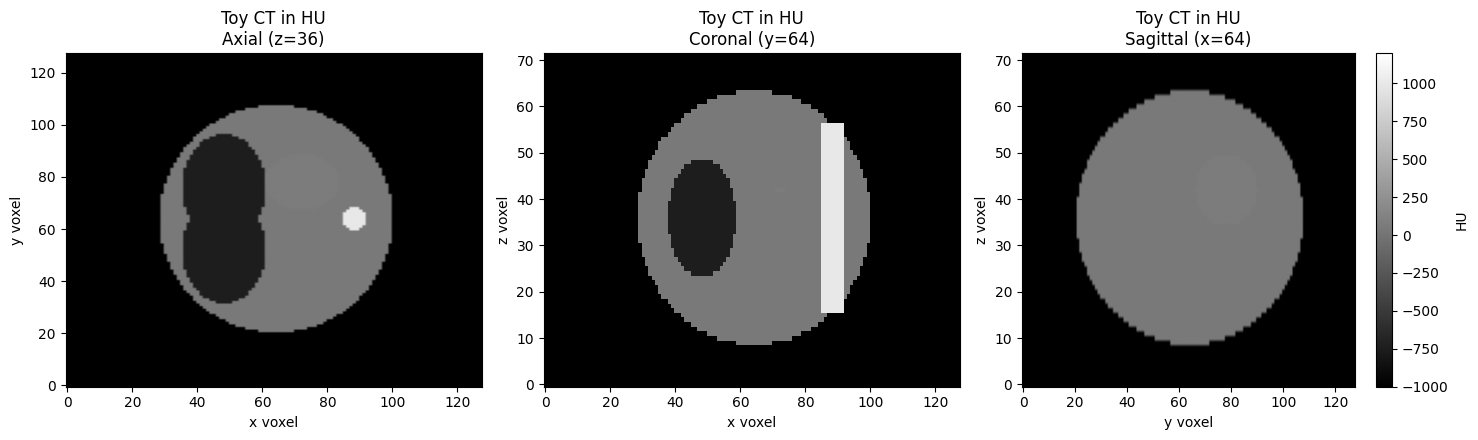

In [27]:

toy_ct_img = sitk.ReadImage(str(toy_ct_hu_path))
toy_ct_arr = sitk.GetArrayFromImage(toy_ct_img)

print("Toy CT size (x, y, z):", toy_ct_img.GetSize())
print("Toy CT spacing (mm):  ", toy_ct_img.GetSpacing())
print("Toy CT origin:        ", toy_ct_img.GetOrigin())
print("Toy CT direction:     ", toy_ct_img.GetDirection())

show_orthogonal_slices(
    toy_ct_arr,
    title="Toy CT in HU",
    cmap="gray",
    cbar_label="HU",
    vmin=-1000,
    vmax=1200,
)


## Reusable function: run a dose simulation from a CT in HU

This function is the core notebook engine.

It supports two source modes:

- `source_mode="point"`  
  Small random source sphere for learning the anatomy-image geometry

- `source_mode="voxel"`  
  Activity image becomes a `VoxelSource`

For the patient CT, it uses **OpenGATE's built-in HU-to-material conversion helper** so you do not need to hand-build HU bins in the notebook.

In [ ]:
def run_hu_image_dose_sim(
    ct_hu_nii_path,
    output_dir,
    n_primaries=100000,
    num_threads=1,
    particle="gamma",
    energy_kev=140.0,
    source_mode="point",
    source_radius_mm=3.0,
    source_translation_mm=(0.0, 0.0, 0.0),
    activity_nii_path=None,
    density_tolerance_gcm3=0.05,
    hu_materials_table_path=None,
    hu_densities_table_path=None,
    write_mhd_outputs=True,
):
    '''
    Build and run an OpenGATE simulation using a CT image in HU as the patient geometry.

    This notebook version intentionally uses OpenGATE's built-in
    HU-to-material conversion helper rather than OpenGATE's built-in HU conversion.

    Parameters
    ----------
    ct_hu_nii_path : str or Path
        Path to the CT image in Hounsfield Units.
    output_dir : str or Path
        Folder for OpenGATE outputs.
    n_primaries : int
        Number of Monte Carlo primary histories.
    num_threads : int
        OpenGATE thread count.
    particle : str
        e.g. "gamma" or "e-".
    energy_kev : float
        Monoenergetic source energy in keV.
    source_mode : str
        "point" or "voxel".
    source_radius_mm : float
        Source radius for the point/sphere source.
    source_translation_mm : tuple
        Source translation in mm for source_mode="point".
    activity_nii_path : str or Path or None
        Required when source_mode="voxel".
    density_tolerance_gcm3 : float
        Density tolerance passed to OpenGATE's HU conversion helper.
    hu_materials_table_path : str or Path or None
        Optional advanced override for the OpenGATE HU materials table.
    hu_densities_table_path : str or Path or None
        Optional advanced override for the OpenGATE HU densities table.
    write_mhd_outputs : bool
        Whether to save output images to disk.

    Returns
    -------
    dict
        Simulation outputs and useful metadata.
    '''
    ct_hu_nii_path = Path(ct_hu_nii_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    ct_img = sitk.ReadImage(str(ct_hu_nii_path))
    size_xyz = ct_img.GetSize()          # x, y, z
    spacing_xyz = ct_img.GetSpacing()    # x, y, z in mm
    physical_size_mm = np.array(size_xyz) * np.array(spacing_xyz)

    mm = gate.g4_units.mm
    keV = gate.g4_units.keV

    sim = gate.Simulation()
    sim.g4_verbose = False
    sim.visu = False
    sim.number_of_threads = int(num_threads)
    sim.random_seed = "auto"
    sim.output_dir = output_dir

    # give the world margin around the CT image box
    world_size_mm = np.maximum(physical_size_mm * 1.4, 400.0) # a bit larger then ct image or at least 40cm in each dimension
    sim.world.size = [world_size_mm[0] * mm, world_size_mm[1] * mm, world_size_mm[2] * mm]
    sim.world.material = "G4_AIR"

    # patient volume from CT in HU
    patient = sim.add_volume("Image", "patient")
    patient.image = str(ct_hu_nii_path)
    patient.material = "G4_AIR"

    voxel_materials_auto, generated_materials, used_mat_table, used_den_table = get_gate_hu_voxel_materials(
        sim,
        density_tolerance_gcm3=density_tolerance_gcm3,
        materials_table_path=hu_materials_table_path,
        densities_table_path=hu_densities_table_path,
    )
    patient.voxel_materials = voxel_materials_auto

    if write_mhd_outputs:
        patient.dump_label_image = "patient_material_labels.mhd"

    # source
    if source_mode == "point":
        src = sim.add_source("GenericSource", "src")
        src.particle = particle
        src.n = int(n_primaries)
        src.position.type = "sphere"
        src.position.radius = float(source_radius_mm) * mm
        src.position.translation = [float(v) * mm for v in source_translation_mm]
        src.direction.type = "iso"
        src.energy.type = "mono"
        src.energy.mono = float(energy_kev) * keV

    elif source_mode == "voxel":
        if activity_nii_path is None:
            raise ValueError("activity_nii_path must be provided when source_mode='voxel'")

        activity_nii_path = Path(activity_nii_path)

        src = sim.add_source("VoxelSource", "src")
        src.particle = particle
        src.n = int(n_primaries)
        src.image = str(activity_nii_path)
        src.attached_to = patient
        src.direction.type = "iso"
        src.energy.type = "mono"
        src.energy.mono = float(energy_kev) * keV

        # align activity image center to CT image center
        translation = gate.image.get_translation_between_images_center(
            str(ct_hu_nii_path),
            str(activity_nii_path),
        )
        src.position.translation = translation

    else:
        raise ValueError("source_mode must be 'point' or 'voxel'")

    # statistics
    stats = sim.add_actor("SimulationStatisticsActor", "Stats")

    # dose scoring grid: match the CT grid
    dose = sim.add_actor("DoseActor", "dose")
    dose.attached_to = patient
    dose.size = list(size_xyz) # size of the CT image in voxels
    dose.spacing = [float(s) * mm for s in spacing_xyz]
    dose.dose.active = True
    dose.dose_uncertainty.active = True

    if write_mhd_outputs:
        dose.edep.output_filename = "dose_edep.mhd"
        dose.dose.output_filename = "dose_map.mhd"
        dose.dose_uncertainty.output_filename = "dose_uncertainty.mhd"

    sim.run(start_new_process=True)

    dose_arr = np.asarray(dose.dose.image)
    edep_arr = np.asarray(dose.edep.image)
    unc_arr = np.asarray(dose.dose_uncertainty.image)

    label_image_path = output_dir / "patient_material_labels.mhd"

    return {
        "sim": sim,
        "stats": stats,
        "dose_actor": dose,
        "patient": patient,
        "dose_arr": dose_arr,
        "edep_arr": edep_arr,
        "unc_arr": unc_arr,
        "ct_img": ct_img,
        "size_xyz": size_xyz,
        "spacing_xyz": spacing_xyz,
        "voxel_materials_used": voxel_materials_auto,
        "generated_materials": generated_materials,
        "hu_materials_table_path_used": used_mat_table,
        "hu_densities_table_path_used": used_den_table,
        "label_image_path": label_image_path,
        "output_dir": output_dir,
    }

## First image-based simulation: CT in HU + small random source

Before using a full voxelized activity source, it is smart to verify that:

- the CT image loads correctly
- materials are assigned correctly
- the scoring grid matches the CT geometry
- dose appears where you expect

So we first place a small random source sphere inside the toy anatomy.


In [35]:
toy_point_results = run_hu_image_dose_sim(
    ct_hu_nii_path=toy_ct_hu_path,
    output_dir=Path("toy_ct_point_source"),
    n_primaries=120000,
    num_threads=4,
    particle="gamma",
    energy_kev=140.0,
    source_mode="point",
    source_radius_mm=4.0,
    source_translation_mm=(10.0, 35.0, 15.0),
)

print(toy_point_results["stats"])
print("HU materials table used :", toy_point_results["hu_materials_table_path_used"])
print("HU densities table used :", toy_point_results["hu_densities_table_path_used"])

Dispatching simulation to subprocess ...
Simulation: create MTRunManager with 4 threads
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 


Simulation: STOP. Run: 1. Time: 48.6 seconds.
--------------------------------------------------------------------------------
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
runs                4 
events              480000 
tracks              483318 
steps               55490288 
init                15.605 ms
duration            48.599 s
pps                 9876 
tps                 9945 
sps                 1141799 
start_time          Tue Mar 17 14:03:32 2026 
stop_time           Tue Mar 17 14:04:21 2026 
sim_start_time      0.0 ps
sim_stop_time       1.0 s
threads             4 
arch                Linux 
python              3.11.14 
HU materials table used : /home/jhubadmin/miniconda3/envs/tdt_env/lib/python3.11/site-packages/opengate/tests/data/Schneider2000MaterialsTable.txt
HU de

#### Inspect the resulting dose map


toy_point_dose_arr:
  shape = (72, 128, 128)
  dtype = float64
  min   = 0.0
  max   = 3.948315741429727e-07
  mean  = 1.5269731681908732e-10
  sum   = 0.0001801290843910027

toy_point_unc_arr:
  shape = (72, 128, 128)
  dtype = float64
  min   = 0.0
  max   = 1.0000000000000004
  mean  = 0.09204328667284767
  sum   = 108578.6790370514



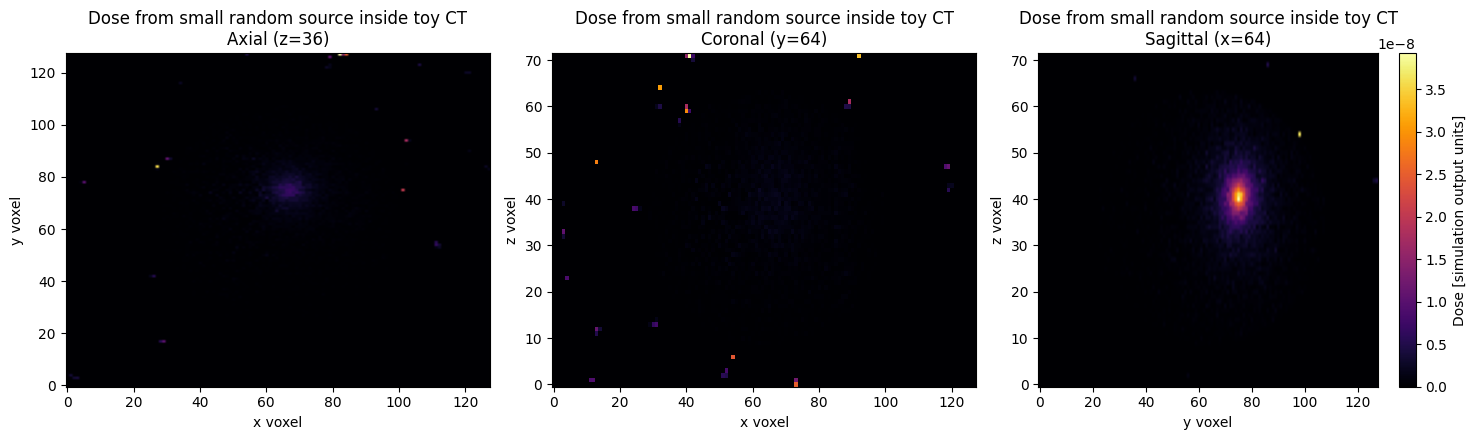

In [36]:

toy_point_dose_arr = toy_point_results["dose_arr"]
toy_point_unc_arr = toy_point_results["unc_arr"]

summarize_array(toy_point_dose_arr, "toy_point_dose_arr")
summarize_array(toy_point_unc_arr, "toy_point_unc_arr")

show_orthogonal_slices(
    toy_point_dose_arr,
    title="Dose from small random source inside toy CT",
    cmap="inferno",
    cbar_label="Dose [simulation output units]",
)


#### Overlay CT HU and the resulting dose


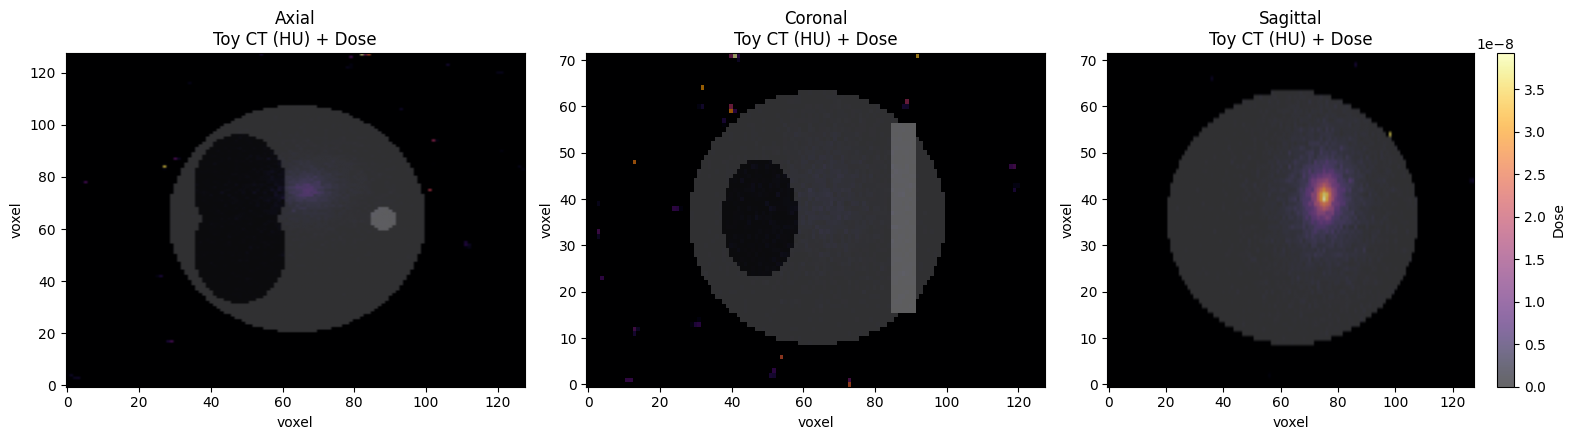

In [37]:

show_overlay_orthogonal(
    toy_ct_arr,
    toy_point_dose_arr,
    background_title="Toy CT (HU)",
    overlay_title="Dose",
    background_cmap="gray",
    overlay_cmap="inferno",
    alpha=0.60,
    bg_vmin=-1000,
    bg_vmax=1200,
)


#### Inspect the material-label image produced by OpenGATE

This is very useful for QA. It lets you confirm that the built-in HU-to-material conversion produced the material regions you expected.

In [40]:

toy_label_path = toy_point_results["label_image_path"]

if toy_label_path.exists():
    toy_label_img = sitk.ReadImage(str(toy_label_path))
    toy_label_arr = sitk.GetArrayFromImage(toy_label_img)

    summarize_array(toy_label_arr, "toy_material_label_arr")
    show_orthogonal_slices(
        toy_label_arr,
        title="Material labels created from toy CT HU",
        cmap="tab20",
        cbar_label="Material label",
    )
else:
    print("No label image found. Check whether patient.dump_label_image was written.")


No label image found. Check whether patient.dump_label_image was written.


## Create a registered toy liver activity map in MBq/mL

Now we build the second required image: a voxelized activity map.

We will create a NIfTI image that:

- has the **same size**
- the **same spacing**
- the **same origin**
- the **same direction**

as the CT image, so that they are physically registered.

Only the liver voxels will be nonzero.


In [41]:

toy_act_path = DATA_DIR / "toy_activity_liver_mbqml.nii.gz"

toy_activity_mbqml = np.zeros_like(toy_ct_hu, dtype=np.float32)

# uniform liver uptake in MBq/mL
toy_activity_mbqml[liver] = 0.35

toy_act_img = sitk.GetImageFromArray(toy_activity_mbqml)
toy_act_img.CopyInformation(toy_ct_img)
sitk.WriteImage(toy_act_img, str(toy_act_path))

print(f"Saved toy activity image to: {toy_act_path}")
summarize_array(toy_activity_mbqml, "toy_activity_mbqml")


Saved toy activity image to: notebook_data_hu/toy_activity_liver_mbqml.nii.gz
toy_activity_mbqml:
  shape = (72, 128, 128)
  dtype = float32
  min   = 0.0
  max   = 0.3499999940395355
  mean  = 0.002497312845662236
  sum   = 2945.9501953125



#### Check that the activity image is truly registered to the CT


CT size      : (128, 128, 72)
Activity size: (128, 128, 72)
CT spacing      : (3.0, 3.0, 3.0)
Activity spacing: (3.0, 3.0, 3.0)
CT origin      : (0.0, 0.0, 0.0)
Activity origin: (0.0, 0.0, 0.0)
CT direction      : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Activity direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

Same size     : True
Same spacing  : True
Same origin   : True
Same direction: True


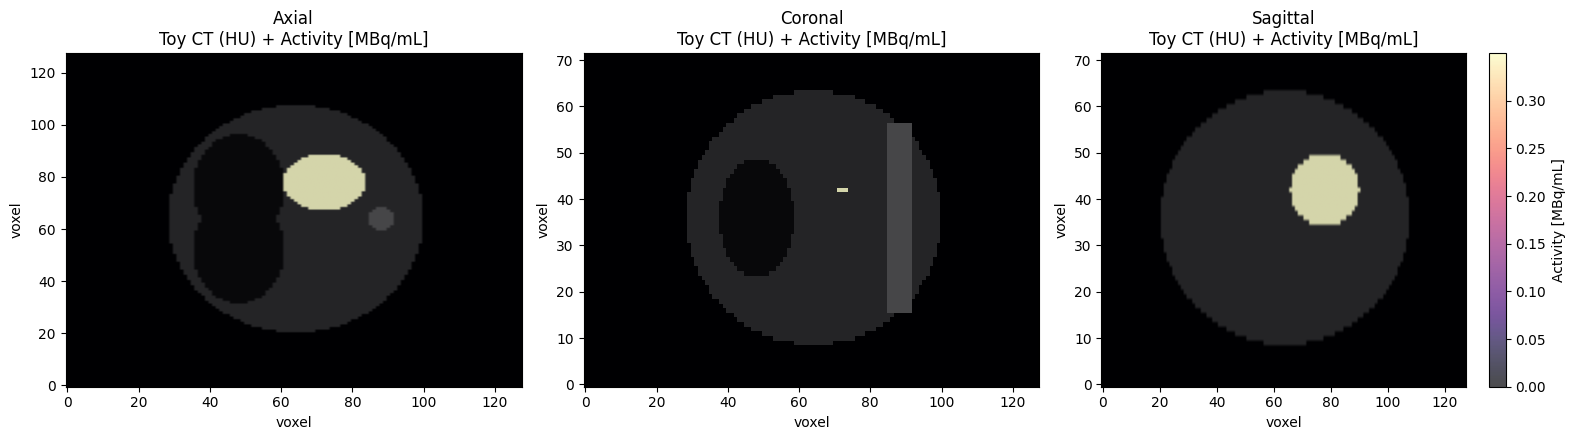

In [42]:

toy_act_img = sitk.ReadImage(str(toy_act_path))
toy_act_arr = sitk.GetArrayFromImage(toy_act_img)

print("CT size      :", toy_ct_img.GetSize())
print("Activity size:", toy_act_img.GetSize())
print("CT spacing      :", toy_ct_img.GetSpacing())
print("Activity spacing:", toy_act_img.GetSpacing())
print("CT origin      :", toy_ct_img.GetOrigin())
print("Activity origin:", toy_act_img.GetOrigin())
print("CT direction      :", toy_ct_img.GetDirection())
print("Activity direction:", toy_act_img.GetDirection())

same_size = toy_ct_img.GetSize() == toy_act_img.GetSize()
same_spacing = np.allclose(toy_ct_img.GetSpacing(), toy_act_img.GetSpacing())
same_origin = np.allclose(toy_ct_img.GetOrigin(), toy_act_img.GetOrigin())
same_direction = np.allclose(toy_ct_img.GetDirection(), toy_act_img.GetDirection())

print()
print("Same size     :", same_size)
print("Same spacing  :", same_spacing)
print("Same origin   :", same_origin)
print("Same direction:", same_direction)

show_overlay_orthogonal(
    toy_ct_arr,
    toy_act_arr,
    background_title="Toy CT (HU)",
    overlay_title="Activity [MBq/mL]",
    background_cmap="gray",
    overlay_cmap="magma",
    alpha=0.70,
    bg_vmin=-1000,
    bg_vmax=1200,
)


## Convert the activity image into a total activity

Your activity image is in **MBq/mL**, but OpenGATE's `VoxelSource` uses the image as a **spatial distribution**.

So we separately compute:

- voxel volume
- total activity in MBq
- total activity in Bq

This is needed later when we scale the raw Monte Carlo result into a **dose-rate-like map for 1 second**.


In [43]:

toy_total_activity_bq, toy_total_activity_mbq, toy_voxel_volume_ml, _, _ = compute_total_activity_bq_from_mbqml(
    toy_act_path
)

print(f"Voxel volume [mL] : {toy_voxel_volume_ml}")
print(f"Total activity [MBq]: {toy_total_activity_mbq}")
print(f"Total activity [Bq] : {toy_total_activity_bq}")


Voxel volume [mL] : 0.027
Total activity [MBq]: 79.5406486454308
Total activity [Bq] : 79540648.6454308


## Inspect the built-in OpenGATE HU conversion setup

This notebook now uses the **built-in OpenGATE HU-to-material conversion helper**.

The next two cells:

1. locate the HU-conversion reference tables automatically from your OpenGATE installation  
2. preview the generated HU intervals so you can see what OpenGATE is doing under the hood

In [44]:
gate_hu_mat_path, gate_hu_den_path = find_gate_hu_material_tables()

print("OpenGATE HU materials table:", gate_hu_mat_path)
print("OpenGATE HU densities table:", gate_hu_den_path)

OpenGATE HU materials table: /home/jhubadmin/miniconda3/envs/tdt_env/lib/python3.11/site-packages/opengate/tests/data/Schneider2000MaterialsTable.txt
OpenGATE HU densities table: /home/jhubadmin/miniconda3/envs/tdt_env/lib/python3.11/site-packages/opengate/tests/data/Schneider2000DensitiesTable.txt


#### Preview the HU intervals generated by OpenGATE

This is optional, but very educational.  
It shows how OpenGATE expands the HU axis into many material intervals automatically.

In [45]:
preview_sim = gate.Simulation()

HU_TO_MATERIALS_AUTO_PREVIEW, preview_materials, preview_mat_path, preview_den_path = get_gate_hu_voxel_materials(
    preview_sim,
    density_tolerance_gcm3=0.05,
    materials_table_path=gate_hu_mat_path,
    densities_table_path=gate_hu_den_path,
)

print("Materials table used:", preview_mat_path)
print("Densities table used:", preview_den_path)
print(f"Number of HU intervals generated: {len(HU_TO_MATERIALS_AUTO_PREVIEW)}")
print("First 15 intervals:")
for row in HU_TO_MATERIALS_AUTO_PREVIEW[:15]:
    print(row)

Materials table used: /home/jhubadmin/miniconda3/envs/tdt_env/lib/python3.11/site-packages/opengate/tests/data/Schneider2000MaterialsTable.txt
Densities table used: /home/jhubadmin/miniconda3/envs/tdt_env/lib/python3.11/site-packages/opengate/tests/data/Schneider2000DensitiesTable.txt
Number of HU intervals generated: 74
First 15 intervals:
[-1050.0, -950.0, 'Air_0']
[-950.0, -901.4421989900839, 'Lung_1']
[-901.4421989900839, -852.8843979801677, 'Lung_2']
[-852.8843979801677, -804.3265969702516, 'Lung_3']
[-804.3265969702516, -755.7687959603354, 'Lung_4']
[-755.7687959603354, -707.2109949504193, 'Lung_5']
[-707.2109949504193, -658.6531939405032, 'Lung_6']
[-658.6531939405032, -610.0953929305871, 'Lung_7']
[-610.0953929305871, -561.5375919206709, 'Lung_8']
[-561.5375919206709, -512.9797909107548, 'Lung_9']
[-512.9797909107548, -464.42198990083864, 'Lung_10']
[-464.42198990083864, -415.8641888909225, 'Lung_11']
[-415.8641888909225, -367.30638788100646, 'Lung_12']
[-367.30638788100646, -3

## Run a voxelized-source simulation from the activity map

Now we switch from a tiny point-like source to the real structure you care about:

- CT in HU defines the patient geometry
- liver activity map defines the source distribution

The source image is normalized internally by OpenGATE and used as a 3D probability map.


In [46]:
N_TOY_VOXEL_HISTORIES = 220000

toy_voxel_results = run_hu_image_dose_sim(
    ct_hu_nii_path=toy_ct_hu_path,
    activity_nii_path=toy_act_path,
    output_dir=Path("toy_ct_voxel_source"),
    n_primaries=N_TOY_VOXEL_HISTORIES,
    num_threads=4,
    particle="gamma",      # educational stand-in
    energy_kev=140.0,
    source_mode="voxel",
)

print(toy_voxel_results["stats"])
print("HU materials table used :", toy_voxel_results["hu_materials_table_path_used"])
print("HU densities table used :", toy_voxel_results["hu_densities_table_path_used"])

Dispatching simulation to subprocess ...
Simulation: create MTRunManager with 4 threads
Simulation: initialize Geometry
Simulation: initialize Physics
Simulation: initialize Source
Simulation: initialize G4RunManager
Simulation: initialize PhysicsEngine after RunManager initialization
Simulation: initialize actors
Simulation: check volumes overlap
--------------------------------------------------------------------------------
Simulation: START (in a new process) 
Simulation: STOP. Run: 1. Time: 88.3 seconds.
--------------------------------------------------------------------------------
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
     Cr_sctns:  Glauber-Gribov Nucl-nucl: 0 eV  ---> 25.6 PeV
runs                4 
events              880000 
tracks              886044 
steps               96555635 
init                12.613 ms
duration         

toy_voxel_dose_arr:
  shape = (72, 128, 128)
  dtype = float64
  min   = 0.0
  max   = 1.1841781115866846e-07
  mean  = 2.6361972795809075e-10
  sum   = 0.00031097848484630585

toy_voxel_unc_arr:
  shape = (72, 128, 128)
  dtype = float64
  min   = 0.0
  max   = 1.0000000000000004
  mean  = 0.08691178131561528
  sum   = 102525.30900540293



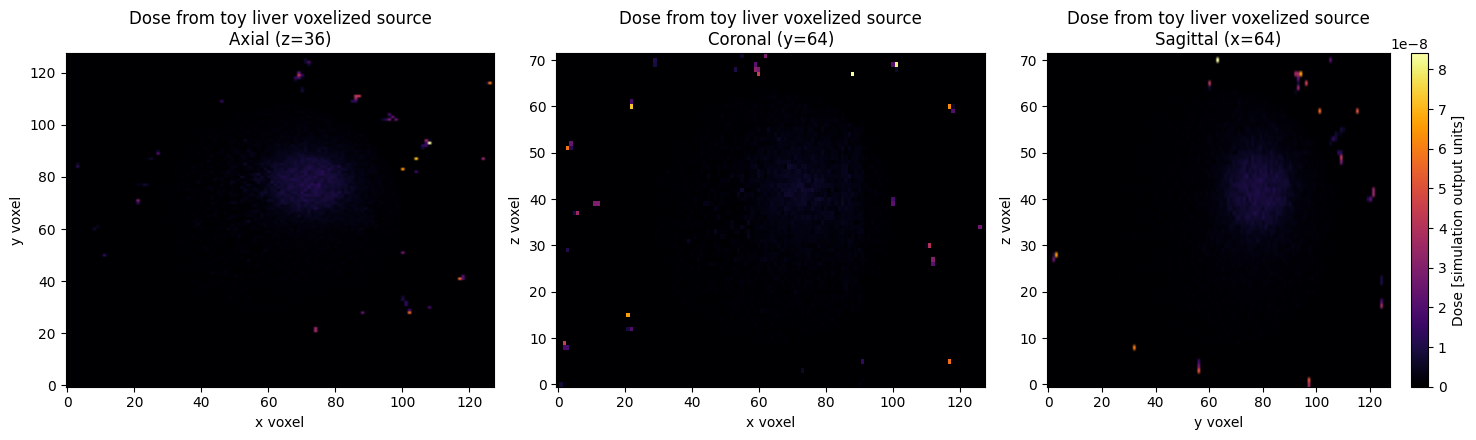

In [47]:

toy_voxel_dose_arr = toy_voxel_results["dose_arr"]
toy_voxel_unc_arr = toy_voxel_results["unc_arr"]

summarize_array(toy_voxel_dose_arr, "toy_voxel_dose_arr")
summarize_array(toy_voxel_unc_arr, "toy_voxel_unc_arr")

show_orthogonal_slices(
    toy_voxel_dose_arr,
    title="Dose from toy liver voxelized source",
    cmap="inferno",
    cbar_label="Dose [simulation output units]",
)


#### Overlay the activity source and resulting dose


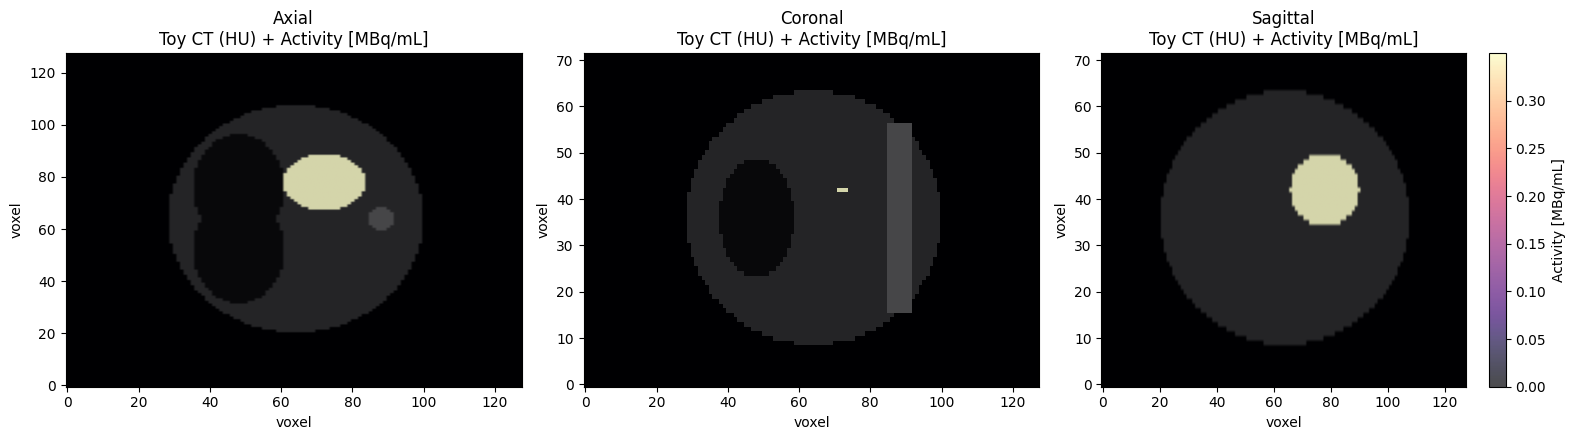

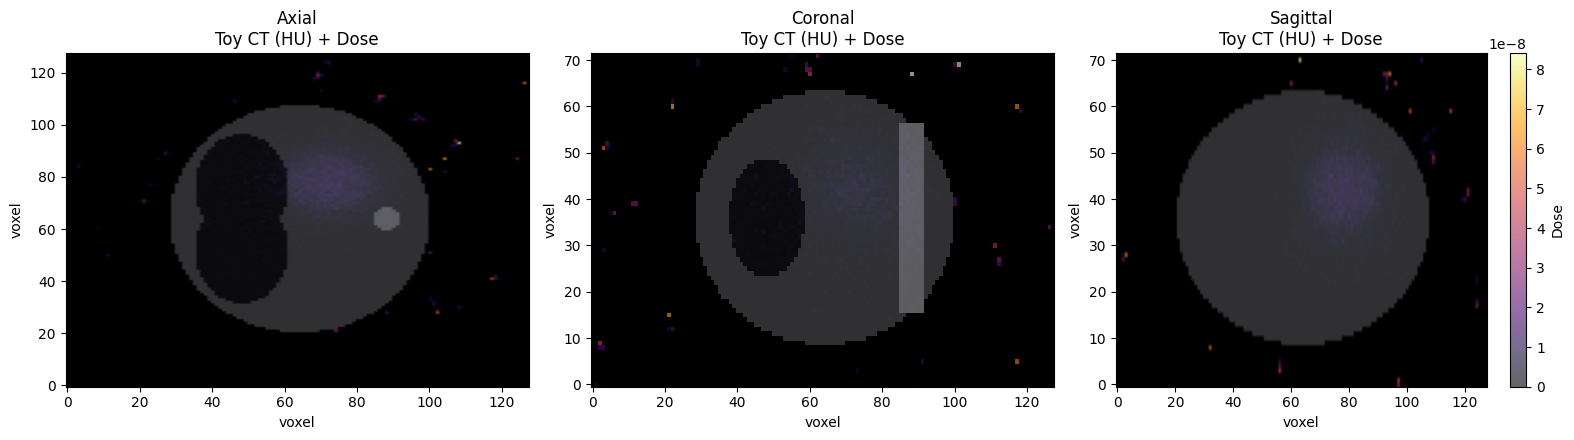

In [48]:

show_overlay_orthogonal(
    toy_ct_arr,
    toy_act_arr,
    background_title="Toy CT (HU)",
    overlay_title="Activity [MBq/mL]",
    background_cmap="gray",
    overlay_cmap="magma",
    alpha=0.70,
    bg_vmin=-1000,
    bg_vmax=1200,
)

show_overlay_orthogonal(
    toy_ct_arr,
    toy_voxel_dose_arr,
    background_title="Toy CT (HU)",
    overlay_title="Dose",
    background_cmap="gray",
    overlay_cmap="inferno",
    alpha=0.60,
    bg_vmin=-1000,
    bg_vmax=1200,
)


## Scale the Monte Carlo output into a dose-rate-like map for 1 second

In this educational setup, we simulated `N_TOY_VOXEL_HISTORIES` particle histories.

A common first approximation is:

- 1 Monte Carlo history ↔ 1 emitted particle / decay sample
- scale factor for 1 second ≈ **total activity [Bq] / simulated histories**

So:

**scaled dose-rate-like image = raw Monte Carlo dose image × total_activity_bq / N_histories**

This is a useful learning step, but remember that exact physical scaling depends on the emission model you use.


Scale factor for 1 second: 361.5484029337764
toy_dose_rate_like_1s:
  shape = (72, 128, 128)
  dtype = float64
  min   = 0.0
  max   = 4.281377050333011e-05
  mean  = 9.53112916250843e-08
  sum   = 0.11243377454294745



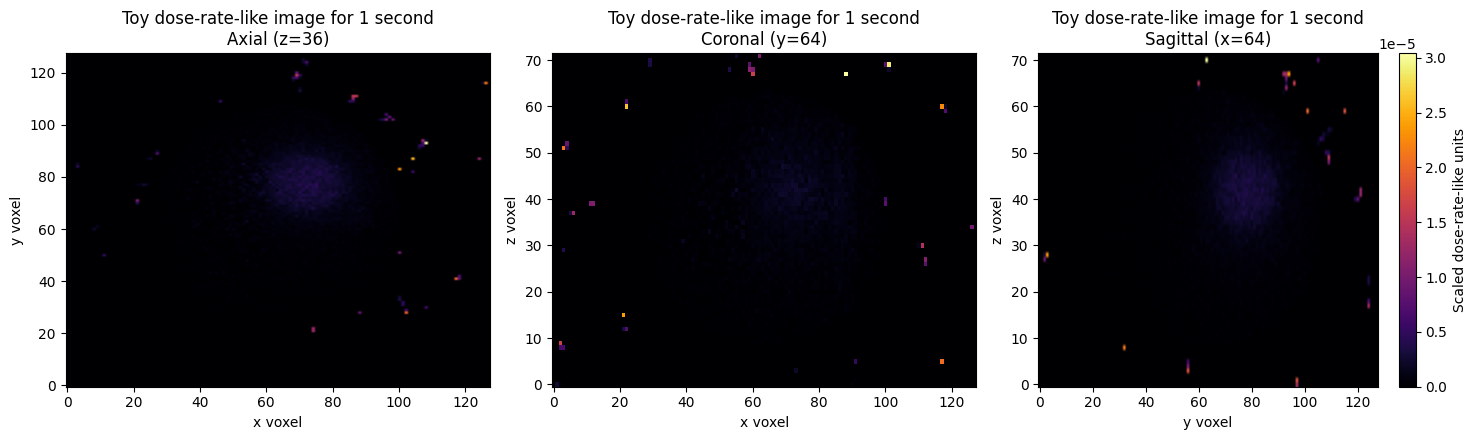

In [50]:

toy_scale_1s = toy_total_activity_bq / N_TOY_VOXEL_HISTORIES
toy_dose_rate_like_1s = toy_voxel_dose_arr * toy_scale_1s

print("Scale factor for 1 second:", toy_scale_1s)
summarize_array(toy_dose_rate_like_1s, "toy_dose_rate_like_1s")

show_orthogonal_slices(
    toy_dose_rate_like_1s,
    title="Toy dose-rate-like image for 1 second",
    cmap="inferno",
    cbar_label="Scaled dose-rate-like units",
)


#### Save the scaled result as NIfTI


In [51]:

toy_scaled_dose_path = DATA_DIR / "toy_dose_rate_like_1s.nii.gz"
save_array_like_reference(toy_ct_img, toy_dose_rate_like_1s, toy_scaled_dose_path)

print(f"Saved scaled toy dose-rate-like NIfTI to: {toy_scaled_dose_path}")


Saved scaled toy dose-rate-like NIfTI to: notebook_data_hu/toy_dose_rate_like_1s.nii.gz
